<a href="https://colab.research.google.com/github/ximenaOr7/ximenaob_mineria/blob/main/179997__naming_colors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Naming colors

If you are shown random colors evenly spaced across the color spectrum, what percentage of those colors would the average person name red? What about green?

English speakers in the United States were shown 80 color chips in random order in controlled lighting condtions. These 80 colors are evenly spaced across the standard Munsell array of colors. The participants were told: "There are 11 choices: black, white, red, green, blue, purple, brown, yellow, orange, pink, gray. Choose the closest color word".

This study was then repeated with Bolivian-Spanish speakers in Bolivia and Tsimane' speakers from the Amazon.

The dataset `munsell-array-fixed-choice.csv` shows the most common name in each language for each color chip.

In [ ]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'munsell-array-fixed-choice.csv'.

# from google.colab import files
# uploaded = files.upload()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("/content/munsell-array-fixed-choice.csv")
df.head()

,grid,x,y,munsell_code,tile_hex,english_color,spanish_color,tsimane_color,spanish,tsimane
0,B1,1,7,5R8/6,#fbb6b0,pink,pink,yellow,rosada (pink),chamus (yellow)
1,D1,1,5,5R6/12,#eb6a68,pink,pink,red,rosada (pink),jainas (red)
2,F1,1,3,5R4/14,#bb1933,red,red,red,rojo (red),jainas (red)
3,H1,1,1,5R2/8,#610d25,red,red,brown,rojo (red),cafedyeisi (brown)
4,A2,2,8,10R9/2,#f2ded8,pink,white,white,blanco (white),jaibas (white)


The function below plots the 80 evenly spaced colors that each study participant was shown in random order.

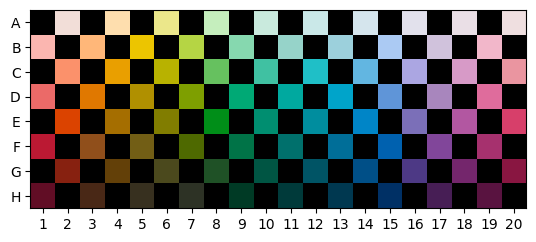

In [ ]:
def plot_colors(color_column):
    fig, ax = plt.subplots()
    for idx, row in df.iterrows():
        ax.add_patch(plt.Rectangle((row['x'] - 0.5, row['y'] - 0.5), 1, 1, color=row[color_column], linewidth=0))

    ax.set_xlim(0.5, 20.5)
    ax.set_ylim(0.5, 8.5)
    ax.set_aspect('equal')
    ax.set_facecolor('black')
    ax.set_xticks(range(1, 21))
    ax.set_yticks(range(1, 9), ['H', 'G', 'F', 'E', 'D', 'C', 'B', 'A'])

plot_colors('tile_hex')

We can also use this function to plot the most common name in each language for each color chip.

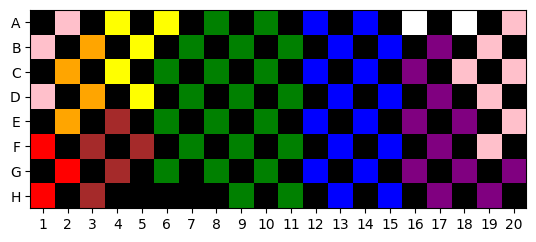

In [ ]:
# Also try 'spanish_color' and 'tsimane_color'
plot_colors('english_color')

### Project Ideas:

- For each language, calculate what percentage of chips are named each color. Return dataframes for each language.

- Create a horizontal bar plot for each language. Each bar represents a color name and the length encodes the percentage of chips that are named that color.

- Is there a correlation between languages? Create scatter plots.
	- Hint: the x-axis could be the percentage of chips for English speakers and the y-axis could be the percentage of chips for Tsimane speakers and each data point represents a color name.

	- You might need to `merge` dataframes.


In [9]:
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = '/content/munsell-array-fixed-choice.csv'

df = pd.read_csv(CSV_PATH)
print("Columnas disponibles:", list(df.columns))
df.head()

Columnas disponibles: ['grid', 'x', 'y', 'munsell_code', 'tile_hex', 'english_color', 'spanish_color', 'tsimane_color', 'spanish', 'tsimane']


,grid,x,y,munsell_code,tile_hex,english_color,spanish_color,tsimane_color,spanish,tsimane
0,B1,1,7,5R8/6,#fbb6b0,pink,pink,yellow,rosada (pink),chamus (yellow)
1,D1,1,5,5R6/12,#eb6a68,pink,pink,red,rosada (pink),jainas (red)
2,F1,1,3,5R4/14,#bb1933,red,red,red,rojo (red),jainas (red)
3,H1,1,1,5R2/8,#610d25,red,red,brown,rojo (red),cafedyeisi (brown)
4,A2,2,8,10R9/2,#f2ded8,pink,white,white,blanco (white),jaibas (white)


In [22]:
# 11 categorías en inglés
BASIC_EN = ['black','white','red','green','blue','purple','brown','yellow','orange','pink','gray']

# Dicc para esdpañol
SPANISH_TO_EN = {
    'negro':'black','blanco':'white','rojo':'red','verde':'green','azul':'blue',
    'morado':'purple','purpura':'purple','púrpura':'purple',
    'cafe':'brown','café':'brown','marron':'brown','marrón':'brown',
    'amarillo':'yellow','naranja':'orange','rosa':'pink','rosado':'pink',
    'gris':'gray',
}

def strip_accents(s):
    return ''.join(c for c in unicodedata.normalize('NFD', str(s)) if unicodedata.category(c) != 'Mn')

def normalize_spanish_to_english(s):
    s2 = strip_accents(str(s).strip().lower())
    return SPANISH_TO_EN.get(s2, s2)

# Nombres de columnas
english_col = 'english_color'
spanish_col = 'spanish_color'
tsimane_col = 'tsimane_color'

#retícula Munsell
x_col, y_col, hex_col = 'x', 'y', 'tile_hex'


In [30]:
# Ingles
en_counts = df[english_col].value_counts()
en_df = en_counts.rename_axis('color').reset_index(name='conteo')
en_df['porcentaje'] = en_df['conteo'] / en_df['conteo'].sum() * 100
en_pct = en_df.set_index('color')['porcentaje']
en_pct.index = [strip_accents(str(i).lower()) for i in en_pct.index]
en_pct = en_pct.reindex(BASIC_EN).fillna(0.0)

#Español
df['_spanish_raw'] = df[spanish_col].astype(str)
df['_spanish_en']  = df['_spanish_raw'].map(normalize_spanish_to_english)
es_df_en = df['_spanish_en'].value_counts().rename_axis('color').reset_index(name='conteo')
es_df_en['porcentaje'] = es_df_en['conteo'] / es_df_en['conteo'].sum() * 100
es_pct = es_df_en.set_index('color')['porcentaje']
es_pct.index = [strip_accents(str(i).lower()) for i in es_pct.index]
es_pct = es_pct.reindex(BASIC_EN).fillna(0.0)

# Tsimane
ct = pd.crosstab(df[tsimane_col], df[english_col])  # matriz tsimane x inglés
ts2en = ct.idxmax(axis=1).to_dict() if not ct.empty else {}
df['_tsimane_en'] = df[tsimane_col].astype(str).map(ts2en).fillna(df[tsimane_col].astype(str))
ts_df_en = df['_tsimane_en'].value_counts().rename_axis('color').reset_index(name='conteo')
ts_df_en['porcentaje'] = ts_df_en['conteo'] / ts_df_en['conteo'].sum() * 100
ts_pct = ts_df_en.set_index('color')['porcentaje']
ts_pct.index = [strip_accents(str(i).lower()) for i in ts_pct.index]
ts_pct = ts_pct.reindex(BASIC_EN).fillna(0.0)

print("Inglés (%):\n", en_pct.round(2))
print("\nEspañol (mapeado a EN) (%):\n", es_pct.round(2))
print("\nTsimane (mapeado a EN) (%):\n", ts_pct.round(2))


Inglés (%):
 black      2.50
white      2.50
red        3.75
green     27.50
blue      20.00
purple    13.75
brown      6.25
yellow     6.25
orange     5.00
pink      12.50
gray       0.00
Name: porcentaje, dtype: float64

Español (mapeado a EN) (%):
 black      2.50
white      7.50
red        5.00
green     27.50
blue       5.00
purple    13.75
brown      5.00
yellow     5.00
orange     5.00
pink      10.00
gray       0.00
Name: porcentaje, dtype: float64

Tsimane (mapeado a EN) (%):
 black      3.75
white      0.00
red        0.00
green     25.00
blue      26.25
purple    12.50
brown      8.75
yellow    13.75
orange     0.00
pink      10.00
gray       0.00
Name: porcentaje, dtype: float64


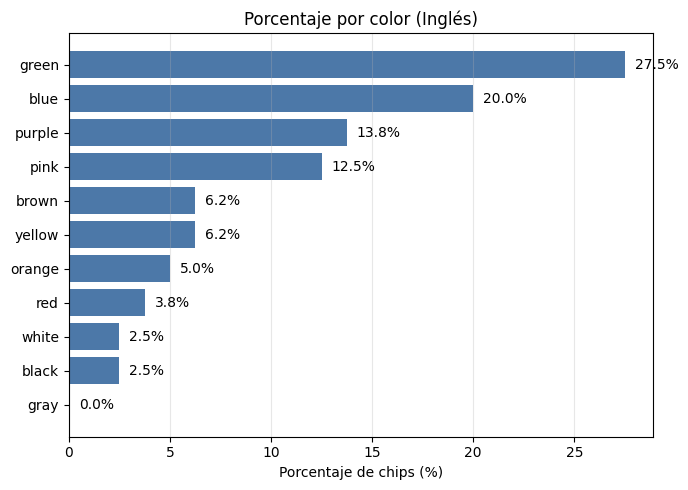

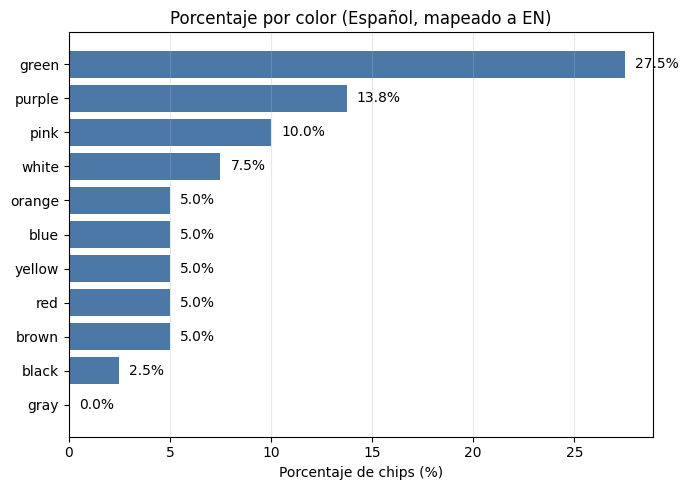

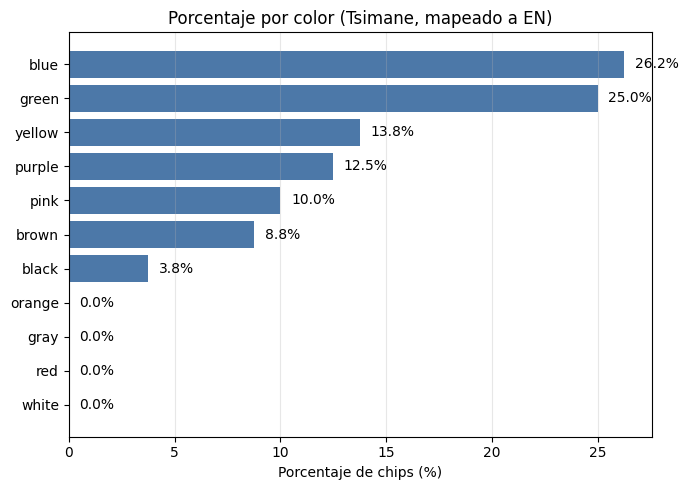

In [29]:
def plot_barh(pct_series, title):
    order = pct_series.sort_values().index
    plt.figure(figsize=(7,5))
    plt.barh(order, pct_series.loc[order].values, color='#4C78A8')
    plt.xlabel('Porcentaje de chips (%)')
    plt.title(title)
    plt.grid(axis='x', alpha=0.3)
    for i, v in enumerate(pct_series.loc[order].values):
        plt.text(v + 0.5, i, f'{v:.1f}%', va='center')
    plt.tight_layout()
    plt.show()

plot_barh(en_pct, 'Porcentaje por color (Inglés)')
plot_barh(es_pct, 'Porcentaje por color (Español, mapeado a EN)')
plot_barh(ts_pct, 'Porcentaje por color (Tsimane, mapeado a EN)')

r Inglés–Español: 0.816
r Inglés–Tsimane: 0.91
r Español–Tsimane: 0.592


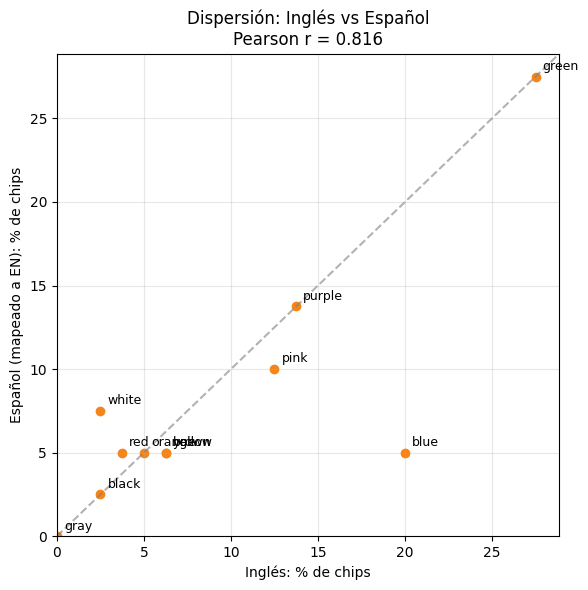

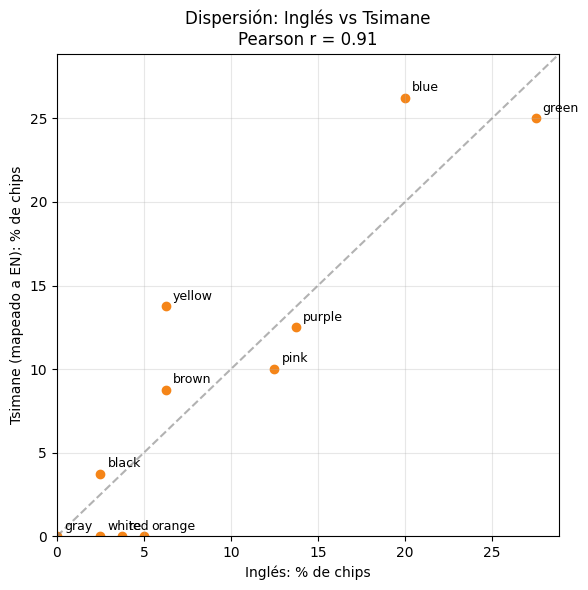

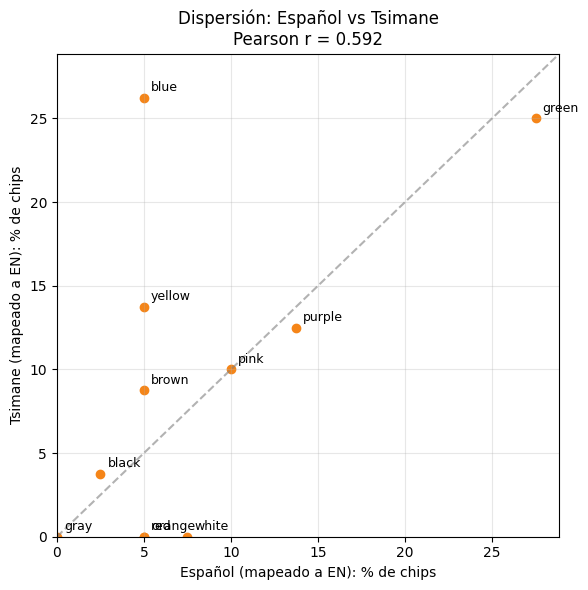

In [28]:
def corr(a, b):
    a, b = np.asarray(a), np.asarray(b)
    if len(a) < 2 or np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    return np.corrcoef(a, b)[0,1]

def plot_scatter(x_ser, y_ser, xlab, ylab, title):
    idx = BASIC_EN
    x = x_ser.reindex(idx).fillna(0.0)
    y = y_ser.reindex(idx).fillna(0.0)
    r = corr(x.values, y.values)

    plt.figure(figsize=(6,6))
    plt.scatter(x, y, color='#F58518')
    for name in idx:
        plt.text(x[name] + 0.4, y[name] + 0.4, name, fontsize=9)
    lim = [0, max(max(x.max(), y.max()) * 1.05, 10)]
    plt.plot(lim, lim, ls='--', color='gray', alpha=0.6)
    plt.xlim(lim); plt.ylim(lim)
    plt.xlabel(xlab); plt.ylabel(ylab); plt.grid(alpha=0.3)
    plt.title(f'{title}\nPearson r = {np.round(r,3) if not np.isnan(r) else r}')
    plt.tight_layout()
    plt.show()

r_en_es = corr(en_pct.values, es_pct.values)
r_en_ts = corr(en_pct.values, ts_pct.values)
r_es_ts = corr(es_pct.values, ts_pct.values)

print(f"r Inglés–Español: {np.round(r_en_es,3)}")
print(f"r Inglés–Tsimane: {np.round(r_en_ts,3)}")
print(f"r Español–Tsimane: {np.round(r_es_ts,3)}")

plot_scatter(en_pct, es_pct, 'Inglés: % de chips', 'Español (mapeado a EN): % de chips', 'Dispersión: Inglés vs Español')
plot_scatter(en_pct, ts_pct, 'Inglés: % de chips', 'Tsimane (mapeado a EN): % de chips', 'Dispersión: Inglés vs Tsimane')
plot_scatter(es_pct, ts_pct, 'Español (mapeado a EN): % de chips', 'Tsimane (mapeado a EN): % de chips', 'Dispersión: Español vs Tsimane')

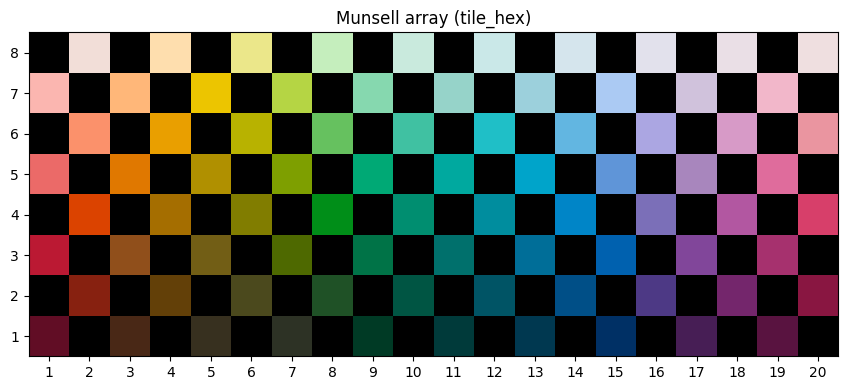

In [26]:
if set([x_col, y_col, hex_col]).issubset(df.columns):
    fig, ax = plt.subplots(figsize=(10,4))
    for _, row in df.iterrows():
        ax.add_patch(plt.Rectangle((row[x_col]-0.5, row[y_col]-0.5), 1, 1, color=row[hex_col], linewidth=0))
    ax.set_xlim(0.5, 20.5); ax.set_ylim(0.5, 8.5)
    ax.set_aspect('equal'); ax.set_facecolor('black')
    ax.set_xticks(range(1,21)); ax.set_yticks(range(1,9))
    ax.set_title('Munsell array (tile_hex)')
    plt.tight_layout(); plt.show()
else:
    print("No se encontraron columnas x y")

In [27]:
# DataFrames con porcentajes
en_tbl = en_pct.reset_index()
en_tbl.columns = ['color','porcentaje_en']

es_tbl = es_pct.reset_index()
es_tbl.columns = ['color','porcentaje_es_mapeado']

ts_tbl = ts_pct.reset_index()
ts_tbl.columns = ['color','porcentaje_ts_mapeado']

# CSV
en_tbl.to_csv('/content/porcentajes_ingles.csv', index=False)
es_tbl.to_csv('/content/porcentajes_espanol_mapeado.csv', index=False)
ts_tbl.to_csv('/content/porcentajes_tsimane_mapeado.csv', index=False)

with pd.ExcelWriter('/content/porcentajes_colores.xlsx', engine='openpyxl') as writer:
    en_tbl.to_excel(writer, sheet_name='ingles', index=False)
    es_tbl.to_excel(writer, sheet_name='espanol_mapeado', index=False)
    ts_tbl.to_excel(writer, sheet_name='tsimane_mapeado', index=False)

print("Archivos guardados en /content:")
print("- porcentajes_ingles.csv")
print("- porcentajes_espanol_mapeado.csv")
print("- porcentajes_tsimane_mapeado.csv")
print("- porcentajes_colores.xlsx")

Archivos guardados en /content:
- porcentajes_ingles.csv
- porcentajes_espanol_mapeado.csv
- porcentajes_tsimane_mapeado.csv
- porcentajes_colores.xlsx
